# Compound hot-dry events in contrasting German climate regions

## A reproducible DWD station-data analysis, 1961–2025

**Research question:** How do frequency, duration and timing of compound hot-dry events differ between a drier continental reference region in Brandenburg/Lusatia and a wetter maritime reference region in north-western Germany?

This notebook is the reporting layer of a modular pipeline. Data ingestion, quality control, regional aggregation and event detection are executed by separate Python scripts; this notebook only reads their reproducible outputs.

## Study design

| Region | Stations | Rationale |
|---|---|---|
| Brandenburg/Lusatia | Cottbus, Lindenberg | Drier, more continental reference area with a strong forest and sandy-soil context |
| North-western Germany | Norderney, Bremen | Maritime reference area with strong North Sea influence |

Daily DWD Climate Data Center (CDC) station data are used. The pipeline merges quality-controlled `historical` observations with the current `recent` series, while retaining the source label for every day. The primary analysis uses complete calendar years from 1961 to 2025.

In [12]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import Image, display

sns.set_theme(style='whitegrid', context='notebook')

PROJECT_ROOT = Path.cwd() if (Path.cwd() / 'data').exists() else Path.cwd().parent
PROCESSED_DIR = PROJECT_ROOT / 'data' / 'processed'
OUTPUT_DIR = PROJECT_ROOT / 'data' / 'outputs'

print('Project root:', PROJECT_ROOT)
print('Processed data:', PROCESSED_DIR)
print('Outputs:', OUTPUT_DIR)

Project root: /home/abrax/Documents/forest-climate-extremes
Processed data: /home/abrax/Documents/forest-climate-extremes/data/processed
Outputs: /home/abrax/Documents/forest-climate-extremes/data/outputs


## Data availability and quality control

The core variables are daily mean temperature (`TMK`), daily maximum temperature (`TXK`), daily minimum temperature (`TNK`) and daily precipitation (`RSK`). No missing values are interpolated. A regional day is eligible only if both stations in its region have complete core observations.

In [13]:
quality = pd.read_csv(OUTPUT_DIR / 'data_quality_summary.csv')
core_variables = ['TMK', 'TXK', 'TNK', 'RSK']

quality.loc[quality['variable'].isin(core_variables)].pivot(
    index='station_name', columns='variable', values='completeness_pct'
).round(2)

variable,RSK,TMK,TNK,TXK
station_name,,,,
Bremen,99.87,99.94,100.00,100.00
Cottbus,99.98,99.37,99.33,98.89
Lindenberg,100.00,99.97,99.84,99.96
Norderney,91.64,99.87,91.98,91.98


In [14]:
with open(OUTPUT_DIR / 'analysis_preparation_summary.json', encoding='utf-8') as file:
    import json
    preparation_summary = json.load(file)

pd.DataFrame(preparation_summary['region_summary'])

,region,days,complete_days,complete_pct
0,brandenburg_lusatia,23741,23734,99.971
1,northwest,23741,23737,99.983


## Compound hot-dry event definition

The primary definition is deliberately strict and uses a fixed historical baseline:

- **Warm season:** April–September
- **Threshold baseline:** 1961–1990
- **Heat condition:** regional daily maximum temperature (`TXK`) at or above the calendar-day-specific 90th percentile, calculated in a plus/minus 15-day baseline window
- **Dry condition:** antecedent 30-day precipitation sum (`RSK`) at or below the calendar-day-specific 10th percentile
- **Compound event:** at least three consecutive days fulfilling both conditions

The precipitation metric is interpreted as an antecedent meteorological precipitation deficit, not as direct soil-moisture drought. A later extension can compare these results with DWD forest soil-moisture products or SPI.

In [15]:
thresholds = pd.read_csv(OUTPUT_DIR / 'compound_hot_dry_thresholds.csv')
config = json.loads((OUTPUT_DIR / 'compound_hot_dry_config.json').read_text(encoding='utf-8'))

pd.DataFrame([config]).T.rename(columns={0: 'value'})

,value
analysis_period,1961-01-01 to 2025-12-31
warm_season,April to September
baseline_period,1961-01-01 to 1990-12-31
calendar_window_days,15
heat_definition,TXK >= calendar-day-specific p90
dry_definition_primary,antecedent 30-day RSK sum <= calendar-day-spec...
event_definition,at least 3 consecutive compound days
sensitivity_dry_threshold_p20_created,True
missing_data_policy,No imputation; incomplete regional days cannot...


## Annual event trends

Annual event statistics are assessed with a Kendall rank trend test and Theil-Sen slope estimate. These are initial monotonic trend diagnostics; they do not establish causality and do not yet adjust for serial autocorrelation or station inhomogeneities.

In [16]:
annual = pd.read_csv(OUTPUT_DIR / 'compound_hot_dry_annual_p10.csv')
trend = pd.read_csv(OUTPUT_DIR / 'compound_hot_dry_trend_statistics.csv')
events = pd.read_csv(OUTPUT_DIR / 'compound_hot_dry_events_p10.csv')

trend.round(4)

,region,metric,n_years,kendall_tau,p_value,theil_sen_slope_per_year,theil_sen_slope_ci_lower,theil_sen_slope_ci_upper,theil_sen_intercept
0,brandenburg_lusatia,event_count,65,0.2818,0.0036,0.0,0.0,0.0000,0.0
1,brandenburg_lusatia,event_days,65,0.2741,0.0034,0.0,0.0,0.0781,0.0
2,brandenburg_lusatia,longest_event_days,65,0.2886,0.0022,0.0,0.0,0.0606,0.0
3,northwest,event_count,65,0.2430,0.0117,0.0,0.0,0.0000,0.0
4,northwest,event_days,65,0.2544,0.0063,0.0,0.0,0.0833,0.0
5,northwest,longest_event_days,65,0.2596,0.0060,0.0,0.0,0.0577,0.0


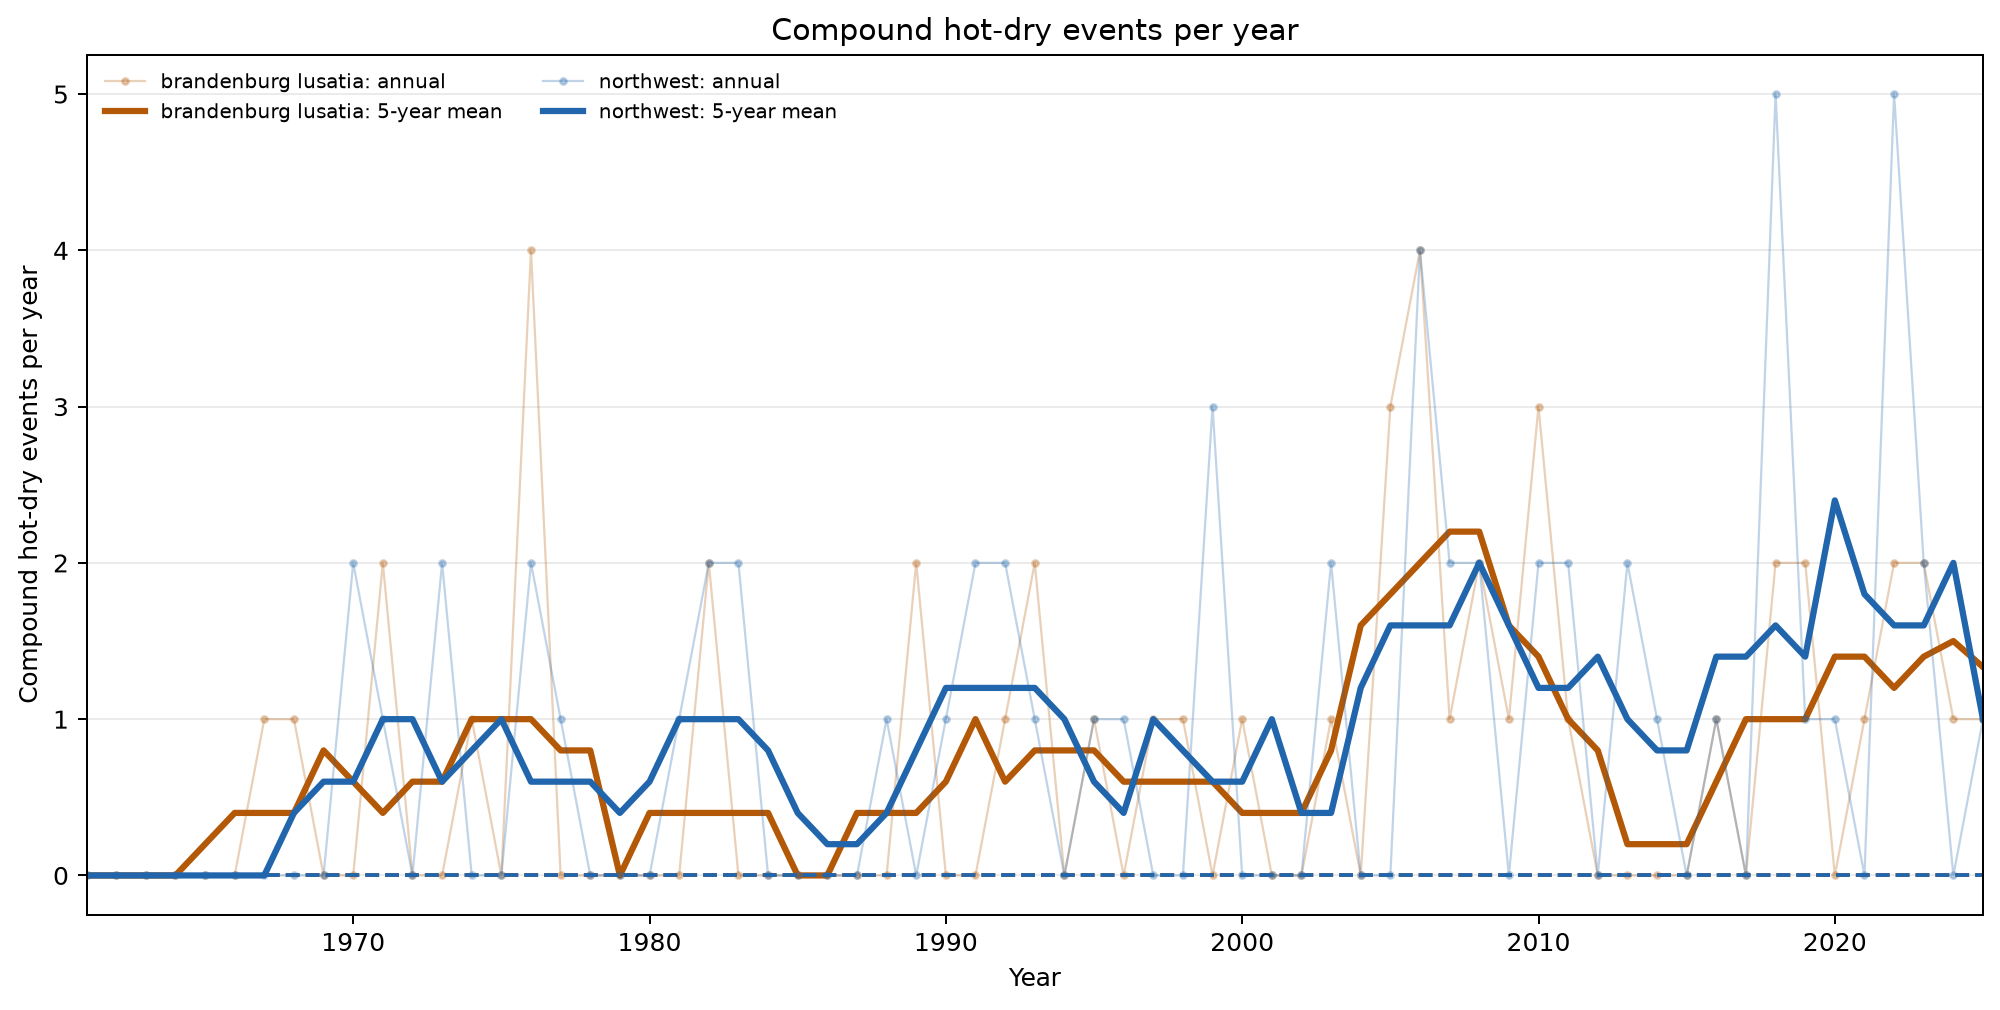

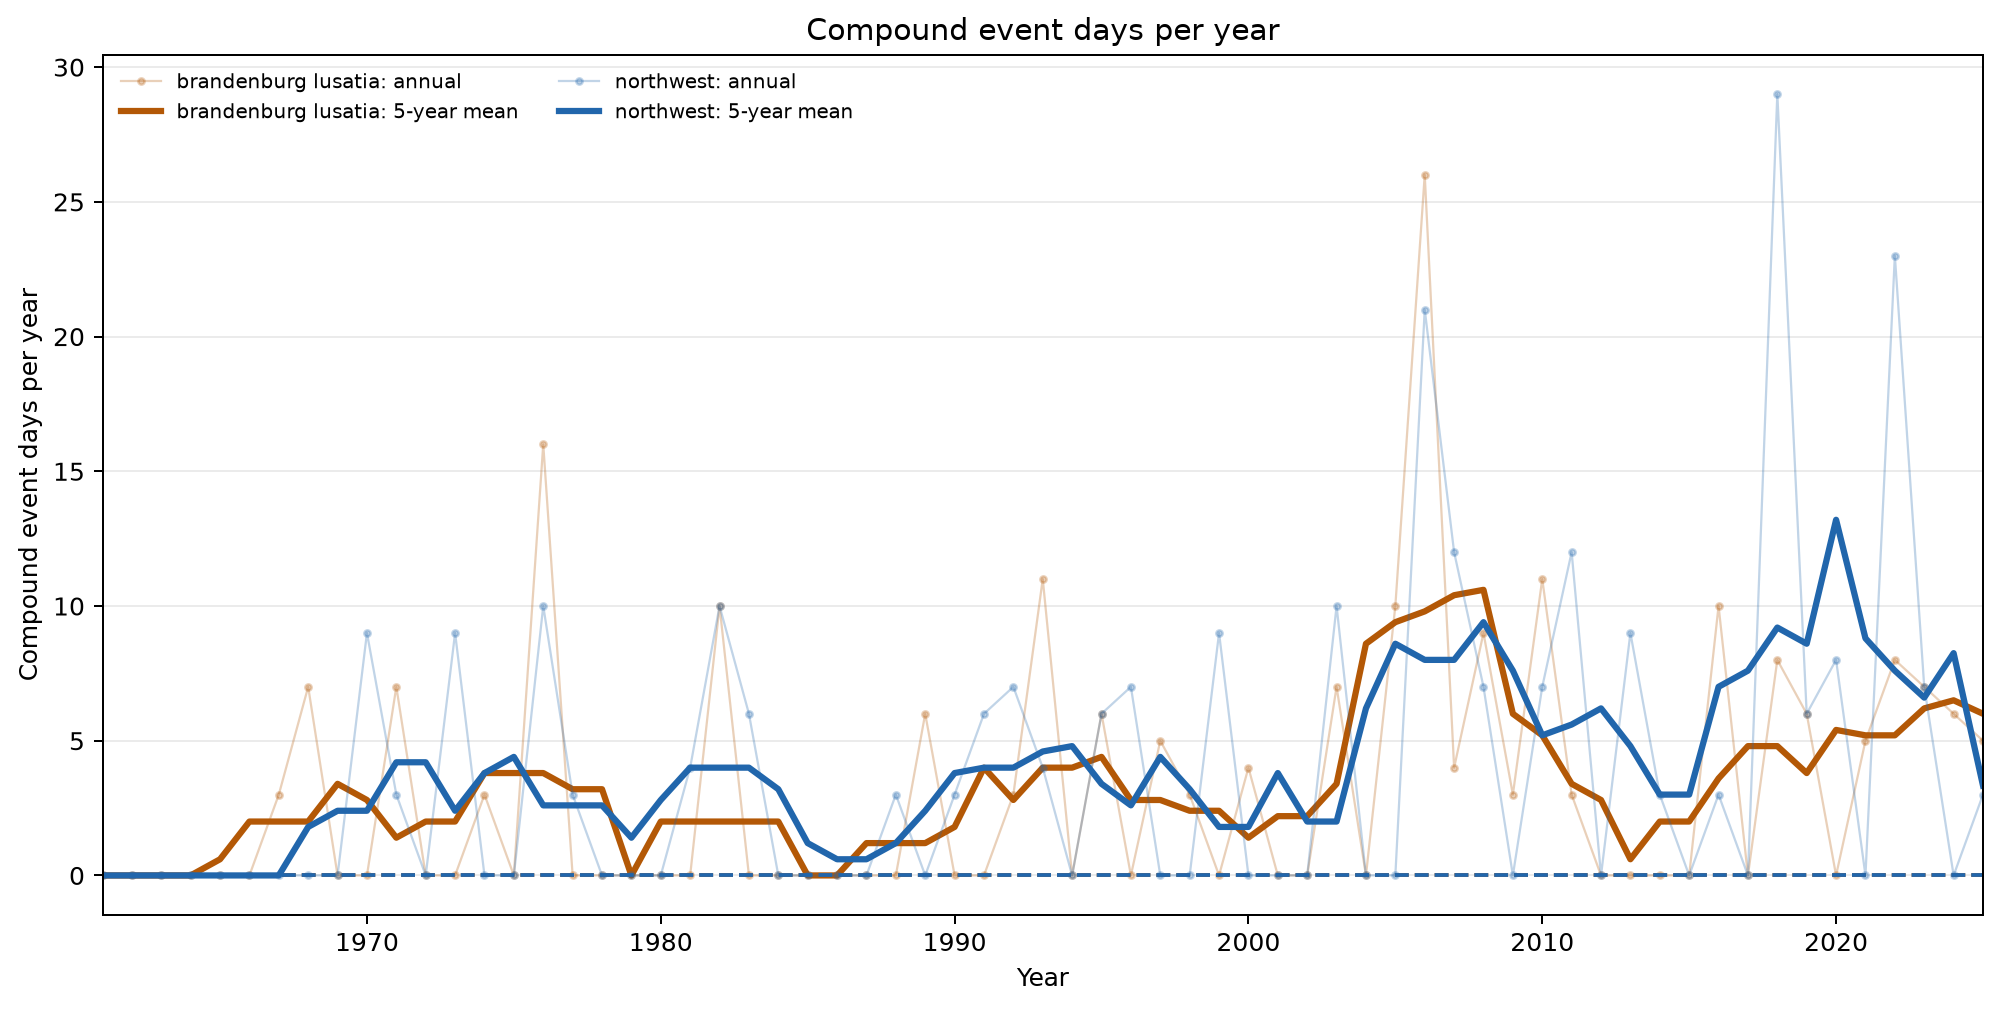

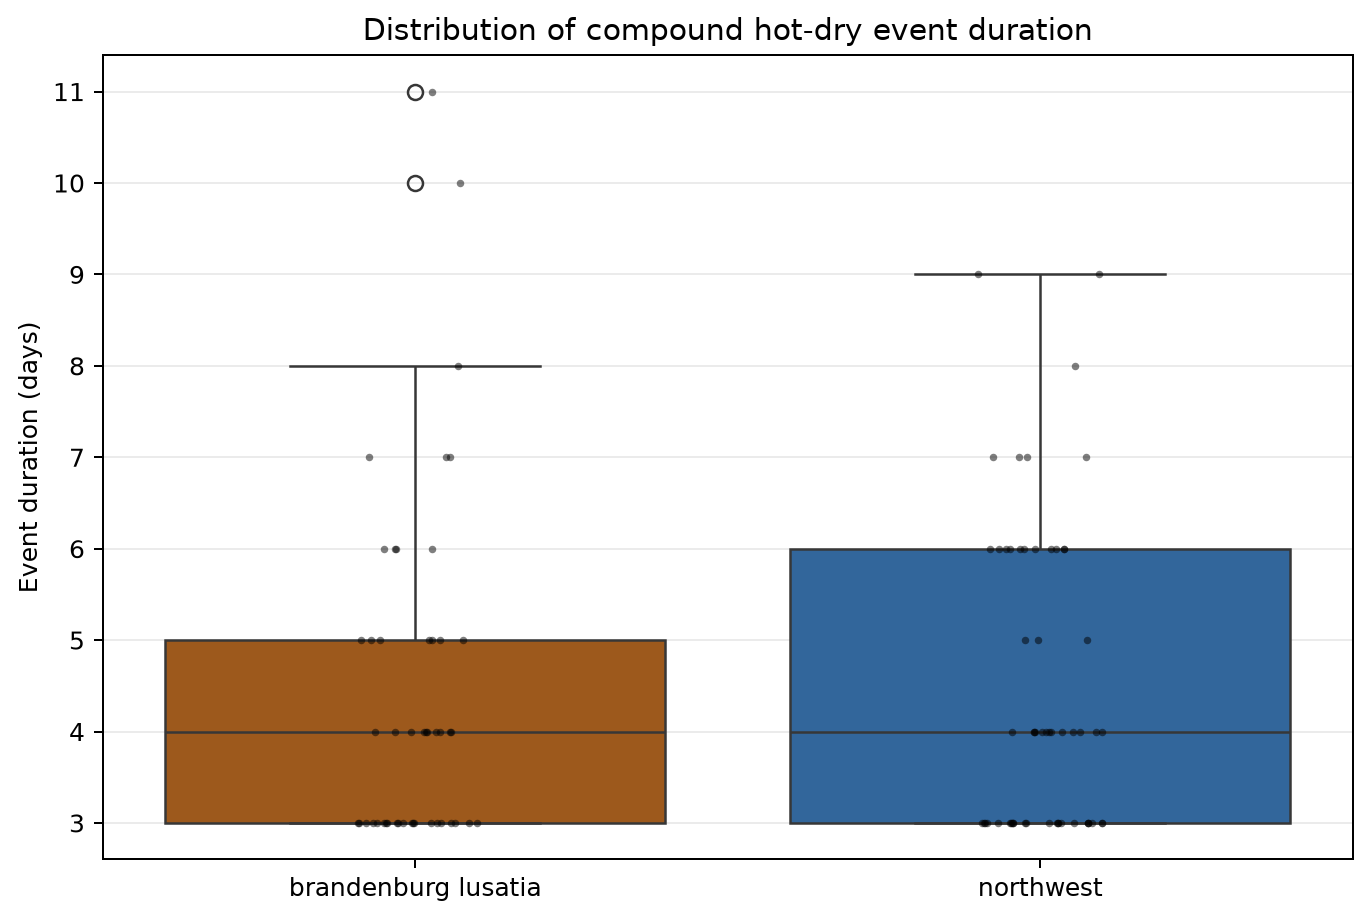

In [17]:
display(Image(filename=OUTPUT_DIR / 'annual_event_count.png'))
display(Image(filename=OUTPUT_DIR / 'annual_event_days.png'))
display(Image(filename=OUTPUT_DIR / 'event_duration_distribution.png'))

## Early-versus-recent comparison

A transparent effect-size comparison complements the rank-based trend tests. The following table compares the first 20 years of the analysis period (1961–1980) with the latest 20 complete years (2006–2025).

In [18]:
metrics = ['event_count', 'event_days', 'longest_event_days']
periods = {
    '1961–1980': annual.query('1961 <= year <= 1980'),
    '2006–2025': annual.query('2006 <= year <= 2025'),
}

comparison_rows = []
for region in sorted(annual['region'].unique()):
    for metric in metrics:
        early = periods['1961–1980'].query('region == @region')[metric].mean()
        recent = periods['2006–2025'].query('region == @region')[metric].mean()
        comparison_rows.append({
            'region': region,
            'metric': metric,
            'mean_1961_1980': early,
            'mean_2006_2025': recent,
            'absolute_difference': recent - early,
            'ratio_recent_to_early': recent / early if early != 0 else float('nan'),
        })

comparison = pd.DataFrame(comparison_rows)
comparison.round(3)

,region,metric,mean_1961_1980,mean_2006_2025,absolute_difference,ratio_recent_to_early
0,brandenburg_lusatia,event_count,0.45,1.20,0.75,2.667
1,brandenburg_lusatia,event_days,1.80,5.55,3.75,3.083
2,brandenburg_lusatia,longest_event_days,1.10,3.70,2.60,3.364
3,northwest,event_count,0.40,1.55,1.15,3.875
4,northwest,event_days,1.70,7.50,5.80,4.412
5,northwest,longest_event_days,1.15,3.80,2.65,3.304


## Strongest identified events

The table below lists the longest events. It is a useful qualitative plausibility check and identifies episodes for later case-study discussion.

In [19]:
events.sort_values(
    ['duration_days', 'maximum_heat_excess'],
    ascending=False,
).head(10).reset_index(drop=True)

,region,event_id,start_date,end_date,duration_days,peak_txk,mean_txk,minimum_precip_30d,mean_heat_excess,maximum_heat_excess,mean_precip_deficit,maximum_precip_deficit,year
0,brandenburg_lusatia,27,2006-07-18,2006-07-28,11,36.05,32.881818,5.00,2.434091,5.550,12.201364,16.600,2006
1,brandenburg_lusatia,37,2016-09-07,2016-09-16,10,32.60,28.905000,14.10,3.007500,6.645,4.567500,6.800,2016
2,northwest,46,2018-07-23,2018-07-31,9,33.25,30.066667,10.55,4.500000,7.700,22.797222,24.990,2018
3,northwest,44,2018-05-24,2018-06-01,9,28.80,25.583333,11.15,2.824444,6.050,7.677778,15.430,2018
4,northwest,50,2020-08-08,2020-08-15,8,32.00,29.262500,22.20,3.814375,6.550,6.113125,10.635,2020
5,brandenburg_lusatia,15,1993-05-07,1993-05-14,8,27.80,26.325000,6.20,1.541875,2.700,10.006875,10.345,1993
6,brandenburg_lusatia,2,1968-04-18,1968-04-24,7,31.00,26.535714,4.80,5.130000,9.200,8.400000,9.800,1968
7,northwest,22,1996-04-17,1996-04-23,7,25.50,21.221429,12.55,4.031429,8.095,2.788571,7.350,1996
8,northwest,33,2007-04-22,2007-04-28,7,25.50,21.378571,2.80,3.252857,7.440,12.825714,15.600,2007
9,northwest,38,2011-04-19,2011-04-25,7,23.30,21.628571,13.40,4.075000,5.400,6.147857,7.100,2011


## Interpretation and limitations

**Preliminary interpretation.** Under the selected, station-based P10 event definition, both regional composites show positive monotonic tendencies in annual compound hot-dry event frequency, total event days and maximum event duration.

**Limitations.** This is an exploratory station-composite analysis. The two-station regional means do not resolve local microclimate or forest-stand conditions; precipitation deficit is not direct soil-water status; the trend tests do not establish causality; and the present MVP does not apply homogenisation or autocorrelation-adjusted trend tests.

**Next extensions.** (1) test a longer common analysis period, subject to data-completeness and homogeneity checks; (2) compare meteorological deficits with DWD forest soil-moisture products; (3) add land-cover and forest context around stations; (4) build a current year-to-date monitoring layer using the `recent` DWD data.

## Data source

German Weather Service (DWD), Climate Data Center (CDC): daily climate observations (`daily/kl`), downloaded through the DWD Open Data service. The repository scripts record the exact DWD URLs used for each ingestion run.

## Current year-to-date monitoring

The monitoring layer applies the fixed 1961–1990 event thresholds to the current DWD station data. The current year is evaluated only up to the latest available observation date and compared with every historical year through the same calendar date.

This prevents an incomplete calendar year from being compared directly with complete historical years.

In [20]:
from pathlib import Path
import json
import pandas as pd

PROJECT_ROOT = (
    Path.cwd()
    if (Path.cwd() / "data").exists()
    else Path.cwd().parent
)

OUTPUT_DIR = PROJECT_ROOT / "data" / "outputs"
monitoring_year = 2026

monitoring_summary = json.loads(
    (
        OUTPUT_DIR / f"current_monitoring_summary_{monitoring_year}.json"
    ).read_text(encoding="utf-8")
)

print(
    "Latest available DWD date:",
    monitoring_summary["latest_available_date"],
)

pd.DataFrame(
    monitoring_summary["regional_summary"]
)

Latest available DWD date: 2026-08-11


,region,complete_days,compound_condition_days,event_days,event_count,longest_event_days,current_ytd_percentile
0,brandenburg_lusatia,133,4,0,0,0,72.31
1,northwest,133,2,0,0,0,52.31


## Sensitivity and robustness analysis

The primary analysis uses a strict P10 antecedent-precipitation threshold. To test whether the main temporal findings depend strongly on this threshold choice, an otherwise identical P20 dry-threshold sensitivity analysis was conducted.

The P20 definition classifies a day as dry when its antecedent 30-day precipitation total falls at or below the calendar-day-specific 20th percentile of the fixed 1961–1990 baseline. All other choices remain unchanged: April–September season, daily maximum-temperature P90, ±15-day calendar window, two-station regional composites, and a minimum event duration of three consecutive compound days.

Additional diagnostics report distributional statistics, Theil–Sen trend estimates, Kendall rank associations, lag-1 autocorrelation, and moving-block bootstrap intervals for paired annual regional differences. P10 remains the primary, stricter event definition.

In [21]:
robustness_comparison = pd.read_csv(
    OUTPUT_DIR / "robustness_threshold_comparison.csv"
)

robustness_trends = pd.read_csv(
    OUTPUT_DIR / "robustness_trend_statistics.csv"
)

robustness_region_difference = pd.read_csv(
    OUTPUT_DIR / "robustness_region_difference.csv"
)

robustness_descriptive = pd.read_csv(
    OUTPUT_DIR / "robustness_descriptive_statistics.csv"
)

robustness_comparison.round(3)

,region,threshold,total_events,years_with_event,total_event_days,mean_event_days_per_year,median_event_days_per_year,median_event_duration,mean_event_duration,maximum_event_duration
0,brandenburg_lusatia,P10,48,29,212,3.262,0.0,4.0,4.417,11
1,brandenburg_lusatia,P20,75,41,328,5.046,3.0,4.0,4.373,12
2,northwest,P10,58,31,259,3.985,0.0,4.0,4.466,9
3,northwest,P20,83,41,376,5.785,4.0,4.0,4.530,10


In [22]:
event_day_trends = robustness_trends.loc[
    robustness_trends["metric"] == "event_days",
    [
        "threshold",
        "region",
        "kendall_tau",
        "kendall_p_value",
        "theil_sen_slope_per_decade",
        "slope_ci_lower_per_decade",
        "slope_ci_upper_per_decade",
        "lag1_autocorrelation",
    ],
].copy()

event_day_trends.round(4)

,threshold,region,kendall_tau,kendall_p_value,theil_sen_slope_per_decade,slope_ci_lower_per_decade,slope_ci_upper_per_decade,lag1_autocorrelation
1,P10,brandenburg_lusatia,0.2741,0.0034,0.0000,0.0,0.7812,0.0621
4,P10,northwest,0.2544,0.0063,0.0000,0.0,0.8333,0.0363
7,P20,brandenburg_lusatia,0.2737,0.0025,0.7208,0.0,1.3793,0.0521
10,P20,northwest,0.3130,0.0005,0.9091,0.0,1.6981,0.0671


### Sensitivity result

Relaxing the dry-condition threshold from P10 to P20 increased the number of identified events in both regions, as expected. Event-duration structure was stable: median duration remained four days under both thresholds and in both regional composites.

Both regions showed positive Kendall associations between year and annual compound-event days under P10 and P20. Under P20, Theil–Sen estimates were approximately 0.72 additional event days per decade in Brandenburg/Lusatia and 0.91 additional event days per decade in the north-western composite. Lag-1 autocorrelation was low for annual event-day series (approximately 0.04–0.07).

The paired moving-block bootstrap intervals for the mean annual difference between Brandenburg/Lusatia and north-western Germany included zero under both thresholds. Therefore, this two-station composite analysis does not support a robust claim that one region experienced a higher average annual compound-event burden than the other. The robust finding is temporal: both regional composites show increasing compound hot-dry event activity under the selected definitions.